In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv()

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("CH17-LangGraph-Modules")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH17-LangGraph-Modules


In [3]:
from typing import Annotated, List, Dict
from typing_extensions import TypedDict

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_teddynote.graphs import visualize_graph
from langchain_teddynote.tools import GoogleNews

#### STEP 1. 상태 정의

In [ ]:
class State(TypedDict):
    # 메시지 목록 주석 추가
    messages: Annotated[list, add_messages]
    # dummy_data: Annotated[str, "dummy"]

#### STEP 2. 도구 정의

In [ ]:
news_tool = GoogleNews()


@tool
def search_keyword(query: str) -> List[Dict[str, str]]:
    """Look up news by keyword"""
    news_tool = GoogleNews()
    return news_tool.search_by_keyword(query, k=5)


tools = [search_keyword]

### STEP 3. Chatbot 노드 정의(함수로 정의)

In [ ]:
# LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini")

# 도구와 LLM 결합
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    # 메시지 호출 및 반환
    return {
        "messages": [llm_with_tools.invoke(state["messages"])]  # ,
        # "dummy_data": "[chatbot] 호출, dummy data",  # 테스트를 위하여 더미 데이터를 추가합니다.
    }

#### STEP 4. 그래프를 구성

In [7]:
# 상태 그래프 생성
graph_builder = StateGraph(State)

# 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)


# 도구 노드 생성 및 추가
tool_node = ToolNode(tools=tools)

# 도구 노드 추가
graph_builder.add_node("tools", tool_node)

# 조건부 엣지
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# chatbot > END
graph_builder.add_edge("chatbot", END)

#### STEP 5. 그래프 컴파일

In [8]:
# 그래프 빌더 컴파일
graph = graph_builder.compile()

#### STEP 6. 그래프 시각화

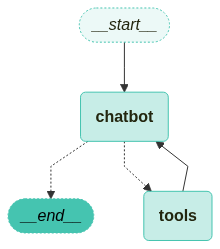

In [9]:
# 그래프 시각화
visualize_graph(graph)

### Stream 단계

#### STEP 1. query 및 state, config 설정

In [10]:
from langchain_core.runnables import RunnableConfig

# 질문
question = "2024년 노벨 문학상 관련 뉴스를 알려주세요."

# 초기 입력 상태를 정의
input = State(messages=[("user", question)])

# config 설정
config = RunnableConfig(
    recursion_limit=10,  # 최대 10개의 노드까지 방문. 그 이상은 RecursionError 발생
    configurable={"thread_id": "1"},  # 스레드 ID 설정
    tags=[
        "my-tag"
    ],  # 이번 실행을 구분하기 위한 태그. 나중에 모니터링 시스템에서 이 태그가 있는 실행만 조회 가능
)

### STEP 2. 실제 Stream의 실행 단계

In [11]:
for event in graph.stream(input=input, config=config):
    for key, value in event.items():
        print(f"\n[ {key} ]\n")
        # value 에 messages 가 존재하는 경우
        if "messages" in value:
            messages = value["messages"]
            # 가장 최근 메시지 1개만 출력합니다.
            value["messages"][-1].pretty_print()


[ chatbot ]

================================== Ai Message ==================================
Tool Calls:
  search_keyword (call_qoXmD9c3QhsBvk1itR8HUPOC)
 Call ID: call_qoXmD9c3QhsBvk1itR8HUPOC
  Args:
    query: 2024년 노벨 문학상

[ tools ]

================================= Tool Message =================================
Name: search_keyword

[{"url": "https://news.google.com/rss/articles/CBMiTkFVX3lxTE1WR2QxeXktVFlQVWE2NUgwVjM4SWJfX0JZVk1Tdm5abWxfQk5NV1FxVmQybnIycF91SmdzNHlaQTBsWEczQ1FuUWFIZUJJdw?oc=5", "content": "[1만호 100대 사건]〈96〉한강, 한국인 최초 노벨문학상 수상 - 전자신문"}, {"url": "https://news.google.com/rss/articles/CBMickFVX3lxTE1uTEo1X21rV25oM0V3c2xpSmpWdTRoQmZ4cWV5WWVKSldPYmZOSFhPcVd0ZUgwdkxoeUdpX2VQQVpLaFZ0QVBRbkdFUzFraVExRE1tcnZlaDZEaHdFM0djVkp1TG83WWc1Yjd0eDgxZldHdw?oc=5", "content": "노벨문학상 한강의 언어들, 어디서 헤엄쳐 왔나 - 한겨레"}, {"url": "https://news.google.com/rss/articles/CBMiWkFVX3lxTFBUN1EyalhQdDFBWms0ZVhzaXlSb0dXXzJXMnlqSGlFUW5SLXNlUU5MSHpQUXhiZC13TlNFRTVOdGp2SEtqckxrLWVDbXZkV0s4blBZU1JlS09EQQ?o

In [ ]:
for event in graph.stream(input=input, config=config, interrupt_after=["tools"]):
    for key, value in event.items():
        print(f"\n[ {key} ]\n")
        # value 에 messages 가 존재하는 경우
        if "messages" in value:
            messages = value["messages"]
            # 가장 최근 메시지 1개만 출력합니다.
            value["messages"][-1].pretty_print()


[ chatbot ]

================================== Ai Message ==================================
Tool Calls:
  search_keyword (call_etQmSqqPl45Ok6TOWCx2SWyP)
 Call ID: call_etQmSqqPl45Ok6TOWCx2SWyP
  Args:
    query: 2024년 노벨 문학상

[ tools ]

================================= Tool Message =================================
Name: search_keyword

[{"url": "https://news.google.com/rss/articles/CBMiTkFVX3lxTE1WR2QxeXktVFlQVWE2NUgwVjM4SWJfX0JZVk1Tdm5abWxfQk5NV1FxVmQybnIycF91SmdzNHlaQTBsWEczQ1FuUWFIZUJJdw?oc=5", "content": "[1만호 100대 사건]〈96〉한강, 한국인 최초 노벨문학상 수상 - 전자신문"}, {"url": "https://news.google.com/rss/articles/CBMickFVX3lxTE1uTEo1X21rV25oM0V3c2xpSmpWdTRoQmZ4cWV5WWVKSldPYmZOSFhPcVd0ZUgwdkxoeUdpX2VQQVpLaFZ0QVBRbkdFUzFraVExRE1tcnZlaDZEaHdFM0djVkp1TG83WWc1Yjd0eDgxZldHdw?oc=5", "content": "노벨문학상 한강의 언어들, 어디서 헤엄쳐 왔나 - 한겨레"}, {"url": "https://news.google.com/rss/articles/CBMiWkFVX3lxTFBUN1EyalhQdDFBWms0ZVhzaXlSb0dXXzJXMnlqSGlFUW5SLXNlUU5MSHpQUXhiZC13TlNFRTVOdGp2SEtqckxrLWVDbXZkV0s4blBZU1JlS09EQQ?o